<a href="https://colab.research.google.com/github/venkataAshish/Data-Analysis/blob/main/automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

file = pd.read_csv("Automobile_data.csv")

Saving Automobile_data.csv to Automobile_data.csv


In [2]:
print("First 5 Records")
print(file.head())

print("\nDataset Shape")
print(file.shape)

print("\nColumn Names")
print(file.columns)

print("\nData Types")
print(file.dtypes)

print("\nMissing Values")
print(file.isnull().sum())

print("\nStatistical Summary")
print(file.describe())

First 5 Records
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compr

EDA

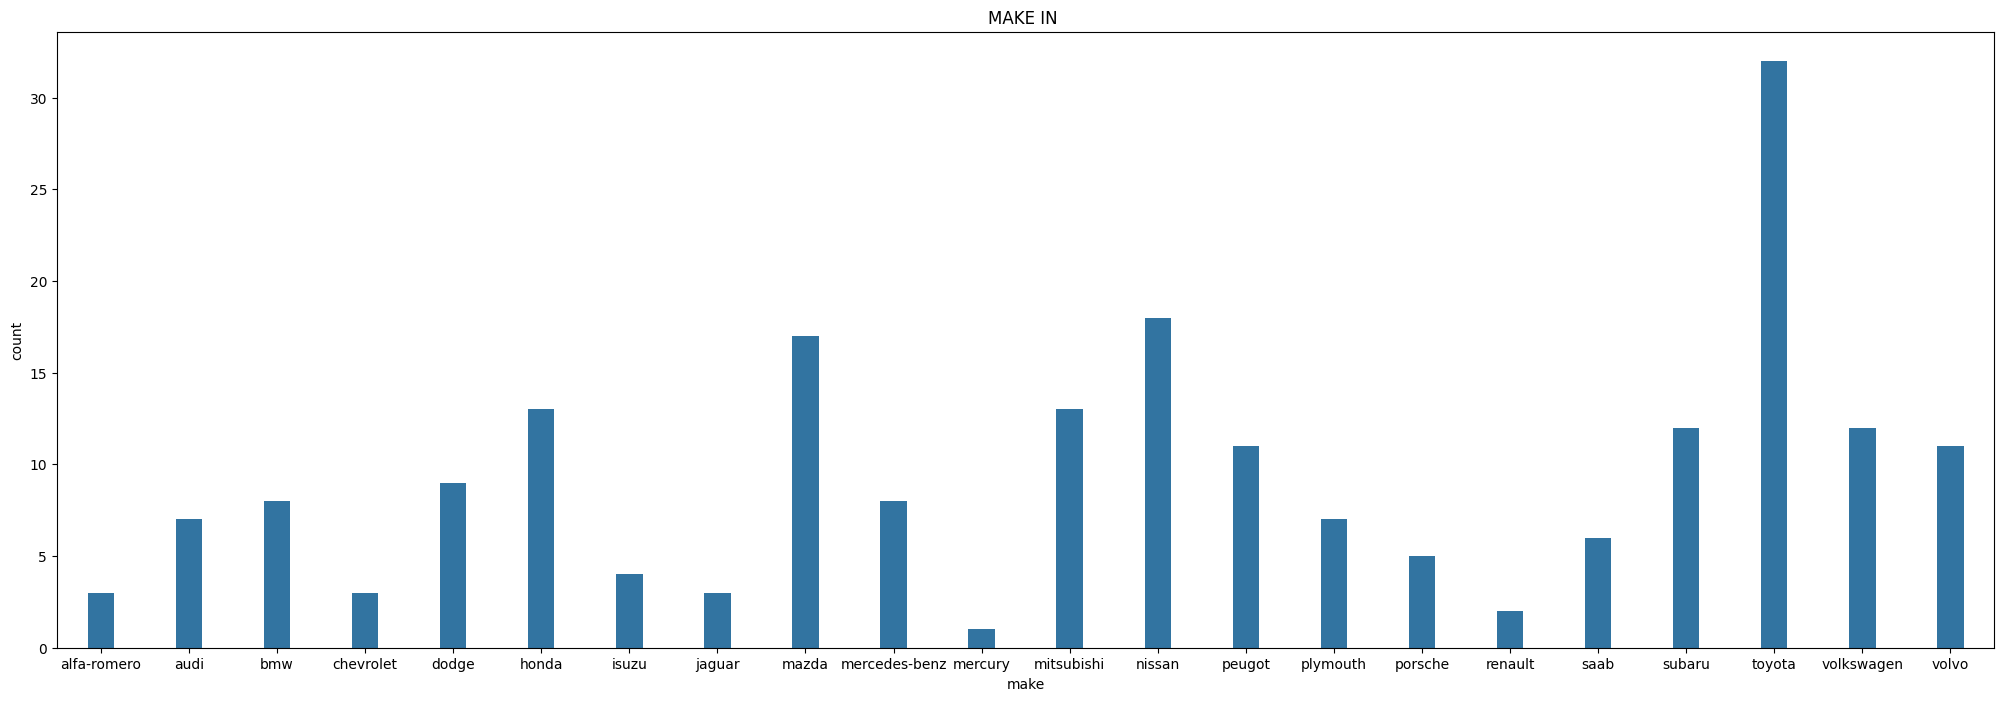

In [3]:
plt.figure(figsize=(25,8))
sns.countplot(x="make" , data=file,width=0.3)
plt.title("MAKE IN ")
plt.show()

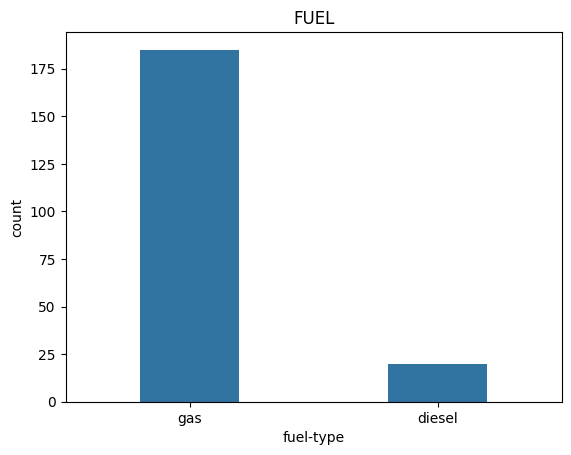

In [4]:
sns.countplot(x="fuel-type", data=file, width =0.4)
plt.title("FUEL")
plt.show()

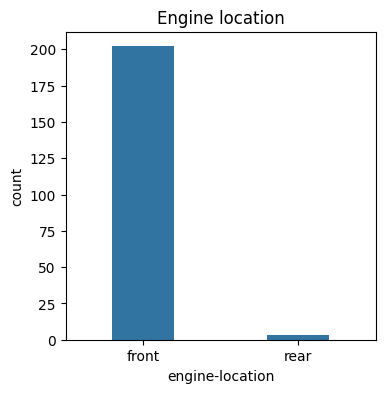

In [5]:
plt.figure(figsize=(4,4))
sns.countplot(x="engine-location",data =file,width=0.4)
plt.title("Engine location")
plt.show()

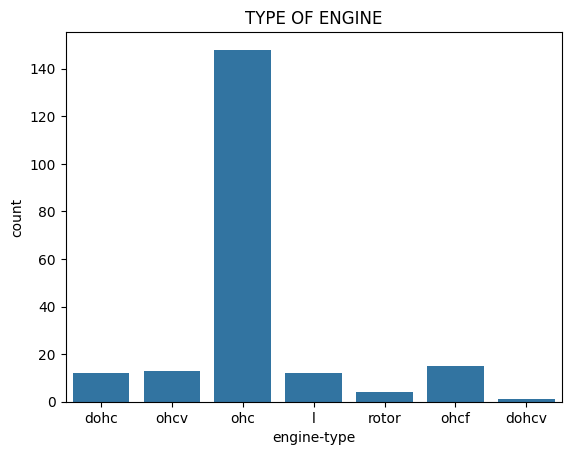

In [6]:
sns.countplot(x="engine-type",data=file)
plt.title("TYPE OF ENGINE")
plt.show()

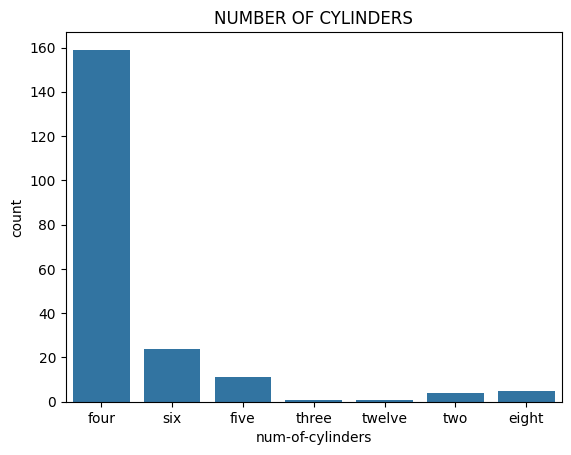

In [7]:
sns.countplot(x='num-of-cylinders',data=file)
plt.title("NUMBER OF CYLINDERS")
plt.show()

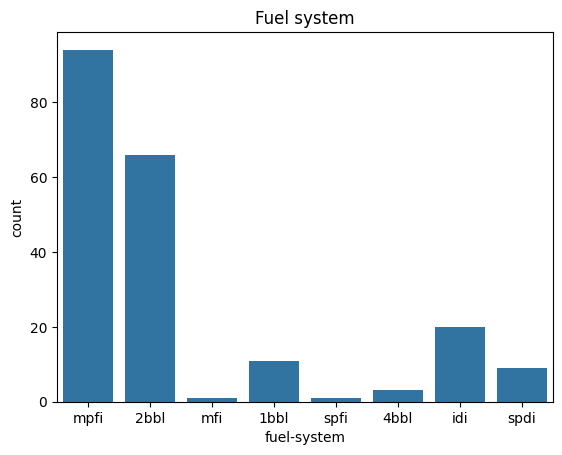

In [8]:
sns.countplot(x="fuel-system",data=file)
plt.title("Fuel system")
plt.show()

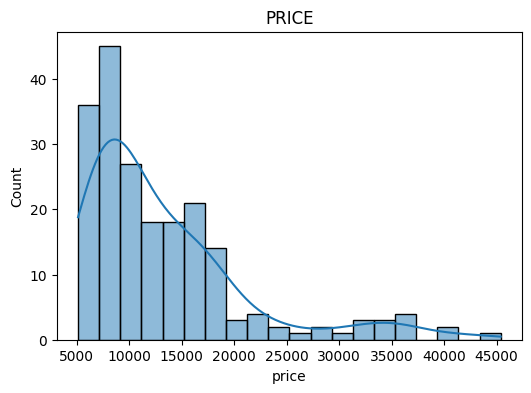

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(file['price'],bins=20,kde=True)
plt.title("PRICE")
plt.show()

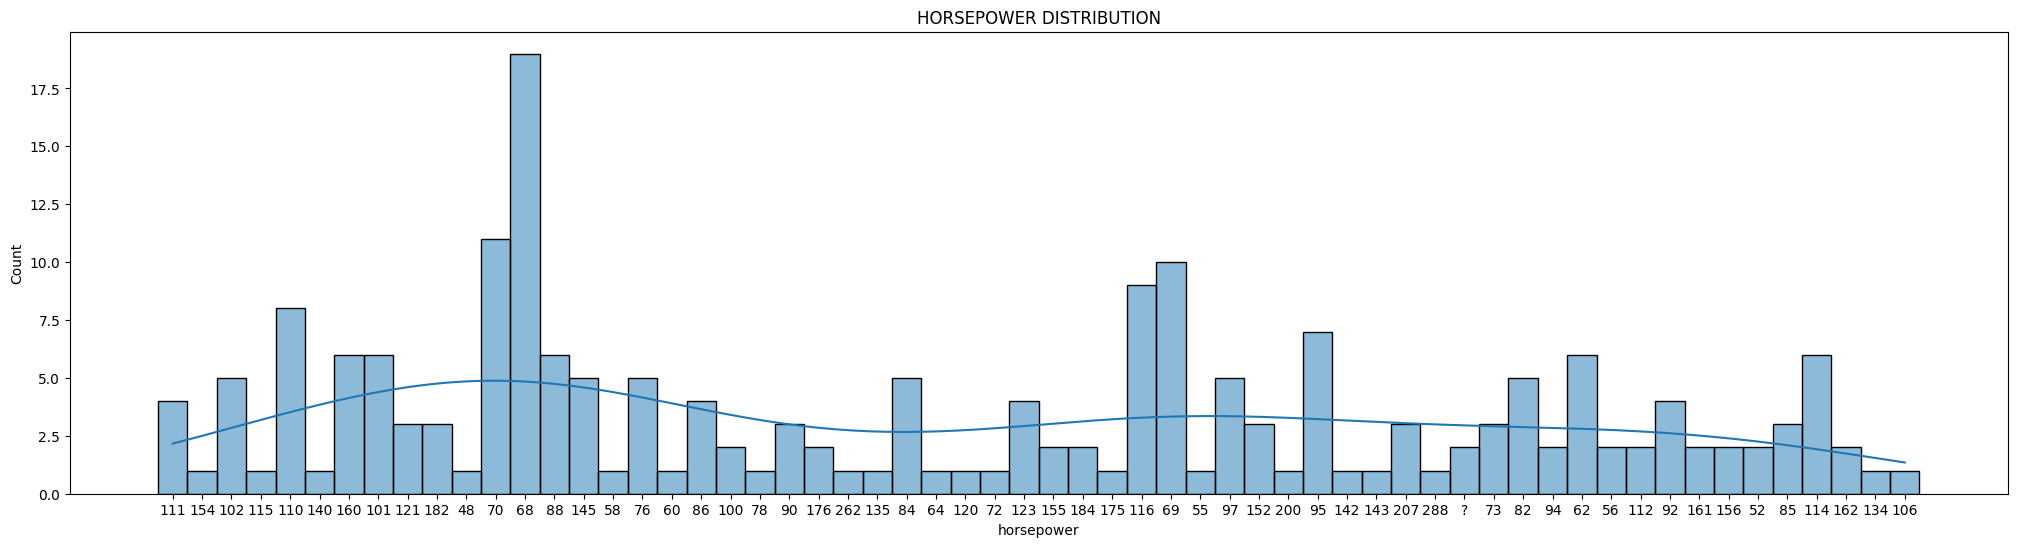

In [23]:
plt.figure(figsize=(25,6))
sns.histplot(file['horsepower'], bins=20,kde=True)
plt.title("HORSEPOWER DISTRIBUTION")
plt.show()

In [10]:
file['price']=file["price"].replace("?" ,pd.NA)
file["price"]=pd.to_numeric(file["price"],errors="coerce")
avgp=file["price"].mean()
file["price"]=file["price"].fillna(avgp)

average_price=file.groupby("make")['price'].mean()
print(average_price)

make
alfa-romero      15498.333333
audi             17194.589908
bmw              26118.750000
chevrolet         6007.000000
dodge             7875.444444
honda             8184.692308
isuzu            11061.814677
jaguar           34600.000000
mazda            10652.882353
mercedes-benz    33647.000000
mercury          16503.000000
mitsubishi        9239.769231
nissan           10415.666667
peugot           15489.090909
plymouth          7963.428571
porsche          27761.825871
renault           9595.000000
saab             15223.333333
subaru            8541.250000
toyota            9885.812500
volkswagen       10077.500000
volvo            18063.181818
Name: price, dtype: float64


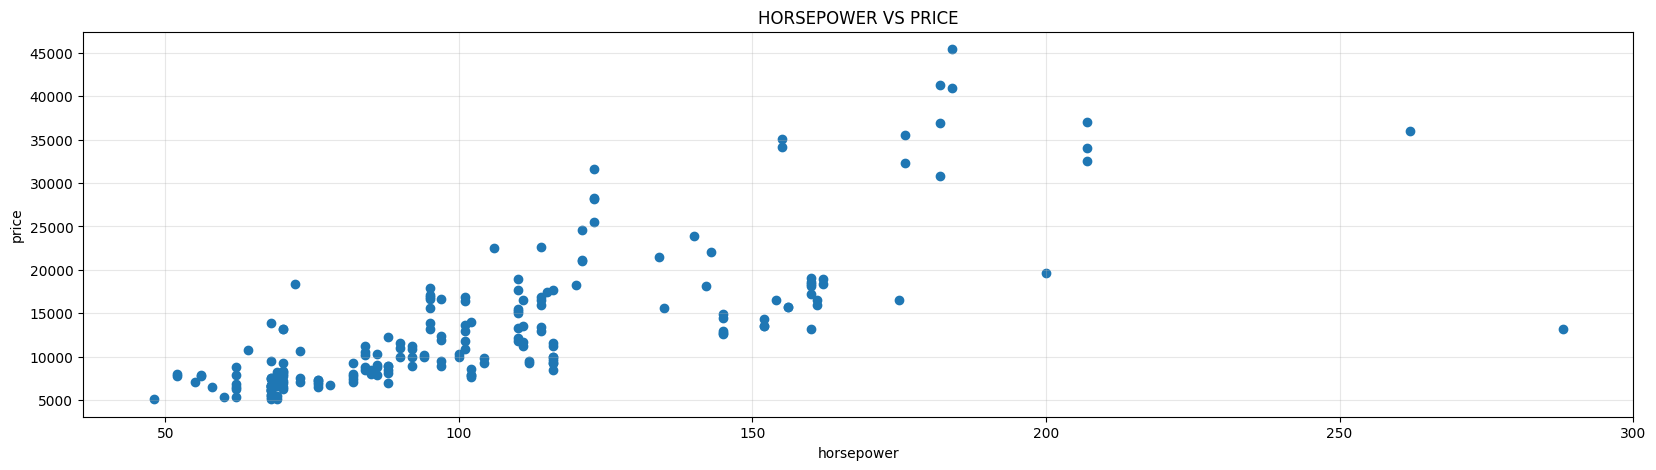

In [27]:
file['horsepower']=file["horsepower"].replace("?" ,pd.NA)
file["horsepower"]=pd.to_numeric(file["horsepower"],errors="coerce")
avgh=file["horsepower"].mean()
file["horsepower"]=file["horsepower"].fillna(avgh)

plt.figure(figsize=(20,5))
plt.scatter(file["horsepower"],file['price'])
plt.xlabel("horsepower")
plt.ylabel("price")
plt.title("HORSEPOWER VS PRICE")
plt.grid(True, alpha=0.3)
plt.show()

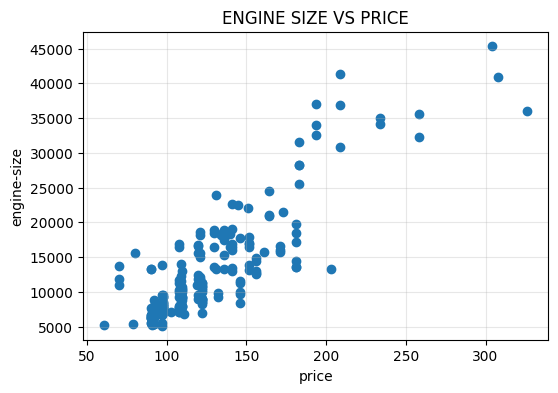

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(file['engine-size'],file["price"])
plt.xlabel('price')
plt.ylabel('engine-size')
plt.title('ENGINE SIZE VS PRICE')
plt.grid(True, alpha=0.3)
plt.show()

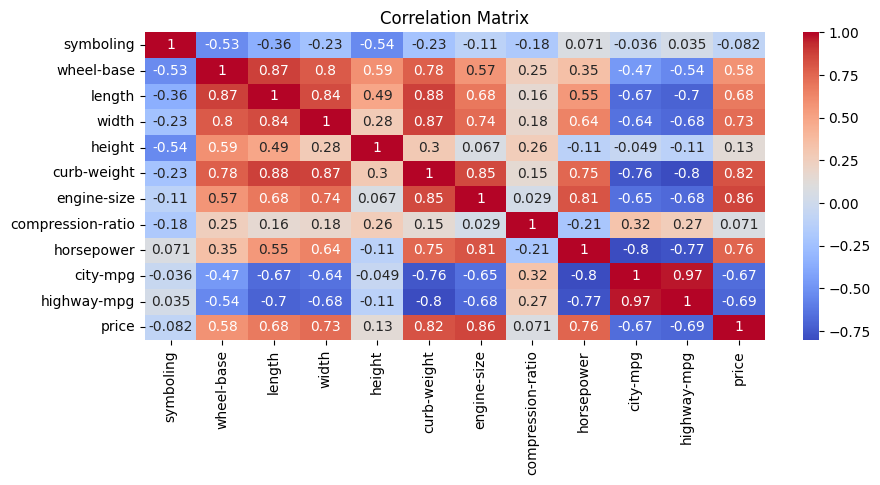

In [31]:
plt.figure(figsize=(10,4))
sns.heatmap(file.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [14]:
print("\nNumeric Attributes")
numeric = file.select_dtypes(include=['int64','float64']).columns
print(numeric)


Numeric Attributes
Index(['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight',
       'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')


In [ ]:
print("\nNominal Attributes")
nominal = ['make','fuel-type','body-style']
print(nominal)


Nominal Attributes
['make', 'fuel-type', 'body-style']


In [33]:
nominal = file.select_dtypes(include='object').columns
print(nominal)

Index(['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'engine-type',
       'num-of-cylinders', 'fuel-system', 'bore', 'stroke', 'peak-rpm'],
      dtype='object')


In [ ]:
print("\nBinary Attributes")
binary = ['fuel-type']
print(binary)


Binary Attributes
['fuel-type']


In [ ]:
make = file['make']
fuel = file['fuel-type']

count = 0
total = 0

for m,f in zip(make,fuel):

    if pd.isna(m) or pd.isna(f):
        continue

    total += 1

    if m != f:
        count += 1

dissimilarity = count / total

print("\nNominal Attribute Dissimilarity")
print("Make vs Fuel Type =", dissimilarity)



Nominal Attribute Dissimilarity
Make vs Fuel Type = 1.0


In [37]:

temp = file[['price','horsepower']].dropna()

price1 = temp.iloc[0]['price']
horse1 = temp.iloc[0]['horsepower']

price2 = temp.iloc[1]['price']
horse2 = temp.iloc[1]['horsepower']




In [39]:
# Euclidean Distance
price1 = pd.to_numeric(price1)
horse1 = pd.to_numeric(horse1)
price2 = pd.to_numeric(price2)
horse2 = pd.to_numeric(horse2)

distance = np.sqrt((price1 - price2)**2 +
                   (horse1 - horse2)**2)

print("\nEuclidean Distance")
print(distance)


Euclidean Distance
3005.0


In [38]:

manhattan = abs(price1 - price2)+abs(horse1-horse2)
print("Manhattan Distance\n")
print(manhattan)

Manhattan Distance

3005.0


In [44]:
minikowski = ((abs(price1-price2)**3)+abs(horse1-horse2)**3)**(1/3)
print("Minikowski distance\n")
print(minikowski.round(2))

Minikowski distance

3005.0


In [53]:
A = np.array([price1,horse1])
B = np.array([price2,horse2])
cos_sim = np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))
cos_dissim = 1-cos_sim
print("Cosine Dissimiliriy\n")
print(cos_dissim)

Cosine Dissimiliriy

1.1218697986148385e-06
